# Deepfake Detection Using Vision Transformers (ViT-B/16)
**CS-419: Deep Learning**
Esthal Fatima (474658) - Emaan Khuram Afroze (481852)
Instructor: Dr. Muhammad Imran Malik

## Step 1: Environment Setup

In [1]:
!pip install numpy==1.26.4 --force-reinstall -q
!pip install transformers==4.38.2 -q
import IPython; IPython.display.clear_output()
print("Environment ready")

Environment ready


In [2]:
import os, shutil
from pathlib import Path

SRC = Path("/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake")
DST = Path("/kaggle/working/data/processed")

mapping = {"train": "train", "valid": "val", "test": "test"}
for src_split, dst_split in mapping.items():
    for label in ["real", "fake"]:
        src = SRC / src_split / label
        dst = DST / dst_split / label
        dst.mkdir(parents=True, exist_ok=True)
        for img in src.glob("*.jpg"):
            (dst / img.name).symlink_to(img.resolve())
        print(f"{dst_split}/{label}: done")

train/real: done
train/fake: done
val/real: done
val/fake: done
test/real: done
test/fake: done


In [3]:
!nvidia-smi
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

Sun May  3 17:44:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install -q transformers==4.38.2 facenet-pytorch gradio scikit-learn timm einops seaborn tqdm
import IPython; IPython.display.clear_output()
print("All dependencies installed")

All dependencies installed


## Step 2: Dataset



## Step 3: Write Project Files

In [5]:
# dataset.py
code = """
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms(image_size=224):
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        T.RandomGrayscale(p=0.05),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.RandomRotation(degrees=5),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def get_val_transforms(image_size=224):
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

class DeepfakeDataset(Dataset):
    LABEL_MAP = {"real": 0, "fake": 1}
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.samples = []
        self.class_counts = [0, 0]
        for label_name, label_int in self.LABEL_MAP.items():
            label_dir = self.root / label_name
            if not label_dir.exists():
                raise FileNotFoundError(f"Not found: {label_dir}")
            for img_path in sorted(label_dir.glob("*.jpg")) + sorted(label_dir.glob("*.png")):
                self.samples.append((img_path, label_int))
                self.class_counts[label_int] += 1
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        return image, label
    def get_sample_weights(self):
        total = len(self.samples)
        w = [total / c for c in self.class_counts]
        return torch.tensor([w[lbl] for _, lbl in self.samples], dtype=torch.float)

def get_dataloaders(data_root, batch_size=32, num_workers=2, image_size=224):
    from torch.utils.data import WeightedRandomSampler
    data_root = Path(data_root)
    train_ds = DeepfakeDataset(data_root/"train", transform=get_train_transforms(image_size))
    val_ds   = DeepfakeDataset(data_root/"val",   transform=get_val_transforms(image_size))
    test_ds  = DeepfakeDataset(data_root/"test",  transform=get_val_transforms(image_size))
    weights = train_ds.get_sample_weights()
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
    return {"train": train_loader, "val": val_loader, "test": test_loader}
"""
with open("dataset.py", "w") as f:
    f.write(code)
print("dataset.py written")

dataset.py written


In [6]:
# model.py
code = """
import torch
import torch.nn as nn
from transformers import ViTForImageClassification

class ViTDeepfakeDetector(nn.Module):
    NUM_BLOCKS_TO_FREEZE = 8
    def __init__(self, pretrained=True, dropout=0.1):
        super().__init__()
        model_name = "google/vit-base-patch16-224-in21k"
        if pretrained:
            self.vit = ViTForImageClassification.from_pretrained(model_name, num_labels=2, ignore_mismatched_sizes=True)
        else:
            from transformers import ViTConfig
            self.vit = ViTForImageClassification(ViTConfig(num_labels=2))
        in_f = self.vit.config.hidden_size
        self.vit.classifier = nn.Sequential(
            nn.LayerNorm(in_f), nn.Dropout(dropout),
            nn.Linear(in_f, 256), nn.GELU(),
            nn.Dropout(dropout/2), nn.Linear(256, 2)
        )
        for p in self.vit.vit.embeddings.parameters():
            p.requires_grad = False
        for i, layer in enumerate(self.vit.vit.encoder.layer):
            if i < self.NUM_BLOCKS_TO_FREEZE:
                for p in layer.parameters():
                    p.requires_grad = False
    def forward(self, x):
        out = self.vit(pixel_values=x, output_attentions=True)
        attns = out.attentions if out.attentions is not None else []
        return out.logits, attns
    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, train

def build_model(pretrained=True, dropout=0.1):
    m = ViTDeepfakeDetector(pretrained=pretrained, dropout=dropout)
    tot, tra = m.count_parameters()
    print(f"ViT-B/16: {tot:,} total | {tra:,} trainable ({100*tra/tot:.1f}%)")
    return m
"""
with open("model.py", "w") as f:
    f.write(code)
print("model.py written")

model.py written


## Step 4: Prepare Dataset

In [7]:
from pathlib import Path

SRC = Path("/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake")
DST = Path("/kaggle/working/data/processed")

mapping = {"train": "train", "valid": "val", "test": "test"}
for src_split, dst_split in mapping.items():
    for label in ["real", "fake"]:
        src = SRC / src_split / label
        dst = DST / dst_split / label
        dst.mkdir(parents=True, exist_ok=True)
        count = 0
        for img in src.glob("*.jpg"):
            link = dst / img.name
            if not link.exists():
                link.symlink_to(img.resolve())
            count += 1
        print(f"{dst_split}/{label}: {count:,} images")

print("Dataset ready!")

train/real: 50,000 images
train/fake: 50,000 images
val/real: 10,000 images
val/fake: 10,000 images
test/real: 10,000 images
test/fake: 10,000 images
Dataset ready!


## Step 5: Build Model

In [8]:
import os
os.chdir("/kaggle/working")


In [9]:
import torch
from model import build_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

model = build_model(pretrained=True).to(DEVICE)
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    logits, attns = model(dummy)
print(f"Output shape : {logits.shape}")
print(f"Attn layers  : {len(attns)}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT-B/16: 85,997,570 total | 28,551,938 trainable (33.2%)
Output shape : torch.Size([2, 2])
Attn layers  : 12


In [10]:
!pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu117 -q
import IPython; IPython.display.clear_output()
print("Done!")

Done!


In [11]:
import os
print(os.getcwd())
print(os.listdir("."))

/kaggle/working
['model.py', '__pycache__', 'dataset.py', 'data', '.virtual_documents']


## Step 6: Training

In [12]:
import torch, torch.nn as nn, numpy as np, json, os
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Subset
from dataset import DeepfakeDataset, get_train_transforms, get_val_transforms
from model import build_model
import random

# ── Reduced dataset ───────────────────────────────────────────
SAMPLES_PER_CLASS = 15000  # 15k real + 15k fake = 30k total

from pathlib import Path
DATA_ROOT = Path("/kaggle/working/data/processed")

train_ds = DeepfakeDataset(DATA_ROOT/"train", transform=get_train_transforms())
val_ds   = DeepfakeDataset(DATA_ROOT/"val",   transform=get_val_transforms())
test_ds  = DeepfakeDataset(DATA_ROOT/"test",  transform=get_val_transforms())

real_idx = [i for i,(p,l) in enumerate(train_ds.samples) if l==0][:SAMPLES_PER_CLASS]
fake_idx = [i for i,(p,l) in enumerate(train_ds.samples) if l==1][:SAMPLES_PER_CLASS]
subset   = real_idx + fake_idx
random.shuffle(subset)
train_sub = Subset(train_ds, subset)

train_loader = DataLoader(train_sub, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_sub):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")

# ── Hyperparameters ───────────────────────────────────────────
EPOCHS       = 10
LR_HEAD      = 1e-3
LR_BACKBONE  = 1e-5
WEIGHT_DECAY = 1e-2
PATIENCE     = 3
CKPT_DIR     = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {DEVICE}")

model = build_model(pretrained=True).to(DEVICE)

optimizer = AdamW([
    {"params": [p for p in model.vit.vit.parameters() if p.requires_grad], "lr": LR_BACKBONE},
    {"params": model.vit.classifier.parameters(), "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
best_auc, patience_ctr, history = 0.0, 0, []

@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_labels, all_probs, total_loss = [], [], 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, _ = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    preds = (all_probs >= 0.5).astype(int)
    return (total_loss/len(loader.dataset),
            roc_auc_score(all_labels, all_probs),
            f1_score(all_labels, preds, zero_division=0),
            accuracy_score(all_labels, preds))

print(f"Starting {EPOCHS} epochs on {len(train_sub):,} images...\n")
for epoch in range(1, EPOCHS+1):
    model.train(); running = 0.0
    pbar = tqdm(loaders["train"] if "loaders" in dir() else
                {"train": train_loader}["train"],
                desc=f"Epoch {epoch:02d}/{EPOCHS}", leave=False)
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    train_loss = running / len(train_loader)
    scheduler.step()
    val_loss, val_auc, val_f1, val_acc = evaluate(val_loader)
    row = dict(epoch=epoch, train_loss=round(train_loss,4),
               val_loss=round(val_loss,4), val_auc=round(val_auc,4),
               val_f1=round(val_f1,4), val_acc=round(val_acc,4))
    history.append(row)
    print(f"Ep {epoch:02d} | train={train_loss:.4f} | val_auc={val_auc:.4f} | F1={val_f1:.4f} | Acc={val_acc:.4f}")
    if val_auc > best_auc:
        best_auc = val_auc; patience_ctr = 0
        torch.save({"model_type":"vit", "state_dict":model.state_dict(),
                    "val_auc":val_auc, "val_f1":val_f1, "val_acc":val_acc},
                   f"{CKPT_DIR}/best_model.pth")
        import shutil
        shutil.copy(f"{CKPT_DIR}/best_model.pth", "/kaggle/working/best_model.pth")
        print(f"  Best AUC={val_auc:.4f} saved + copied to output!")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}"); break

with open(f"{CKPT_DIR}/history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"\nDone! Best val AUC: {best_auc:.4f}")


Train: 30,000 | Val: 20,000 | Test: 20,000
Training on: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT-B/16: 85,997,570 total | 28,551,938 trainable (33.2%)
Starting 10 epochs on 30,000 images...



Epoch 01/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 01/10:   0%|          | 0/937 [00:00<?, ?it/s]

...

Epoch 09/10:   0%|          | 0/937 [00:00<?, ?it/s]

Ep 09 | train=0.2571 | val_auc=0.9933 | F1=0.9628 | Acc=0.9627
  Best AUC=0.9933 saved + copied to output!


Epoch 10/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/937 [00:00<?, ?it/s]

Ep 10 | train=0.2558 | val_auc=0.9935 | F1=0.9631 | Acc=0.9630
  Best AUC=0.9935 saved + copied to output!

Done! Best val AUC: 0.9935


In [13]:
import os, shutil
path = "/kaggle/working/checkpoints/best_model.pth"
if os.path.exists(path):
    print("Checkpoint found! Downloading...")
    from IPython.display import FileLink
    display(FileLink(path))
else:
    print("No checkpoint.")

Checkpoint found! Downloading...


/kaggle/working/checkpoints/best_model.pth

In [14]:
# Save checkpoint to Kaggle output (permanent)
import shutil, os
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

# This saves it to Kaggle's output folder which persists
shutil.copy(
    "/kaggle/working/checkpoints/best_model.pth",
    "/kaggle/working/best_model.pth"
)
print("Checkpoint saved to output! Download it from the Output tab on the right.")

Checkpoint saved to output! Download it from the Output tab on the right.


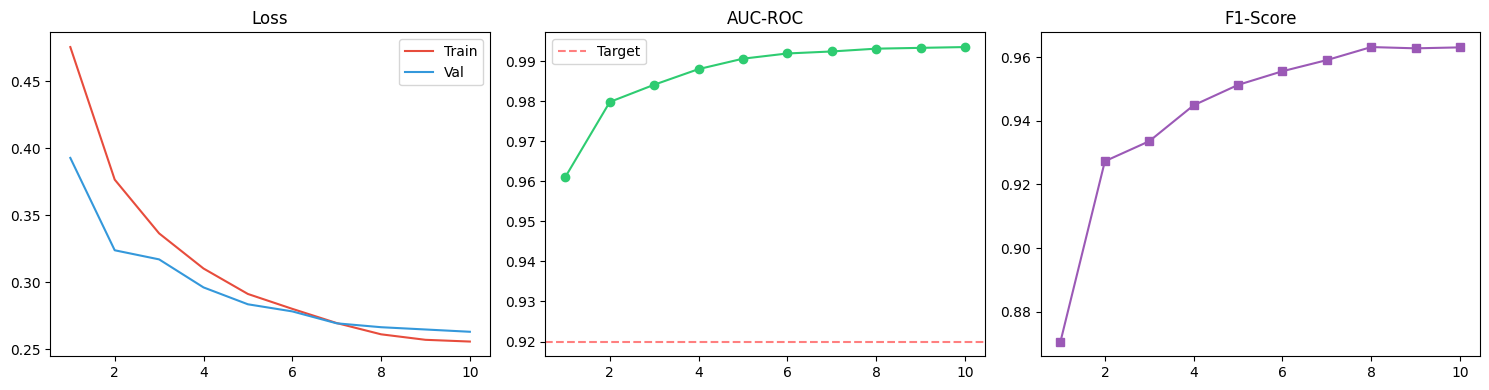

In [15]:
import matplotlib.pyplot as plt, json
with open("checkpoints/history.json") as f: history = json.load(f)
epochs=[h["epoch"] for h in history]
fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].plot(epochs,[h["train_loss"] for h in history],label="Train",color="#e74c3c")
axes[0].plot(epochs,[h["val_loss"]   for h in history],label="Val",  color="#3498db")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs,[h["val_auc"] for h in history],color="#2ecc71",marker="o")
axes[1].axhline(y=0.92,color="red",linestyle="--",alpha=0.5,label="Target"); axes[1].set_title("AUC-ROC"); axes[1].legend()
axes[2].plot(epochs,[h["val_f1"]  for h in history],color="#9b59b6",marker="s"); axes[2].set_title("F1-Score")
plt.tight_layout(); plt.savefig("training_curves.png",dpi=150); plt.show()

## Step 7: Evaluation

ViT-B/16: 85,997,570 total | 28,551,938 trainable (33.2%)
  AUC-ROC     : 0.9936
  F1          : 0.9652
  Accuracy    : 0.9651
  Precision   : 0.9615
  Recall      : 0.9690
              precision    recall  f1-score   support

        Real       0.97      0.96      0.96     10000
        Fake       0.96      0.97      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



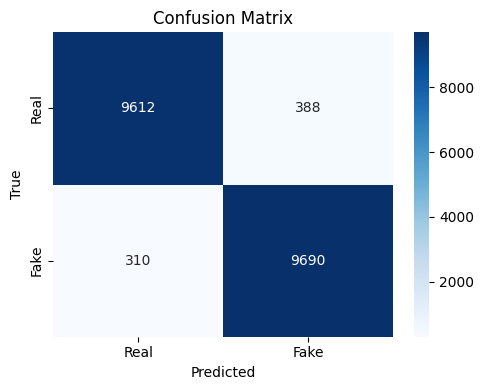

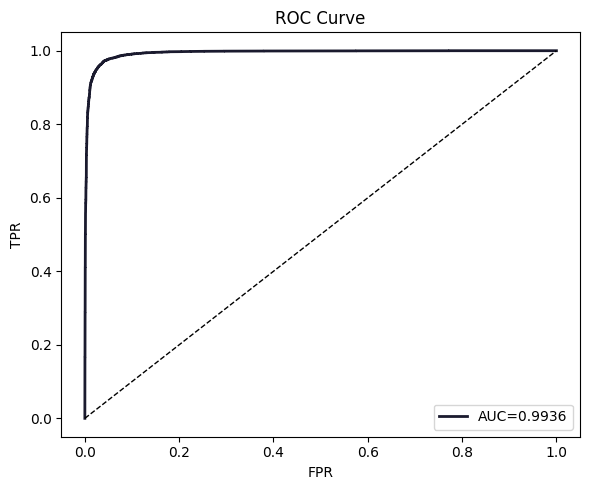

In [16]:
import torch, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix, roc_curve, classification_report)
from dataset import DeepfakeDataset, get_val_transforms
from model   import build_model
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt   = torch.load("best_model.pth", map_location=DEVICE)
model  = build_model(pretrained=False).to(DEVICE)
model.load_state_dict(ckpt["state_dict"]); model.eval()

test_ds     = DeepfakeDataset("data/processed/test", transform=get_val_transforms())
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

all_labels, all_probs = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits, _ = model(imgs.to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        all_probs.extend(probs); all_labels.extend(labels.numpy())

all_labels=np.array(all_labels); all_probs=np.array(all_probs); all_preds=(all_probs>=0.5).astype(int)
metrics = {"AUC-ROC":roc_auc_score(all_labels,all_probs), "F1":f1_score(all_labels,all_preds,zero_division=0),
           "Accuracy":accuracy_score(all_labels,all_preds), "Precision":precision_score(all_labels,all_preds,zero_division=0),
           "Recall":recall_score(all_labels,all_preds,zero_division=0)}
print("="*40)
for k,v in metrics.items(): print(f"  {k:<12}: {v:.4f}")
print("="*40)
print(classification_report(all_labels,all_preds,target_names=["Real","Fake"]))

# Confusion matrix
cm=confusion_matrix(all_labels,all_preds)
fig,ax=plt.subplots(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Real","Fake"],yticklabels=["Real","Fake"],ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
plt.tight_layout(); plt.savefig("confusion_matrix.png",dpi=150); plt.show()

# ROC curve
fpr,tpr,_=roc_curve(all_labels,all_probs)
fig,ax=plt.subplots(figsize=(6,5))
ax.plot(fpr,tpr,color="#1a1a2e",lw=2,label=f"AUC={metrics[chr(65)+'UC-ROC']:.4f}")
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("roc_curve.png",dpi=150); plt.show()

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

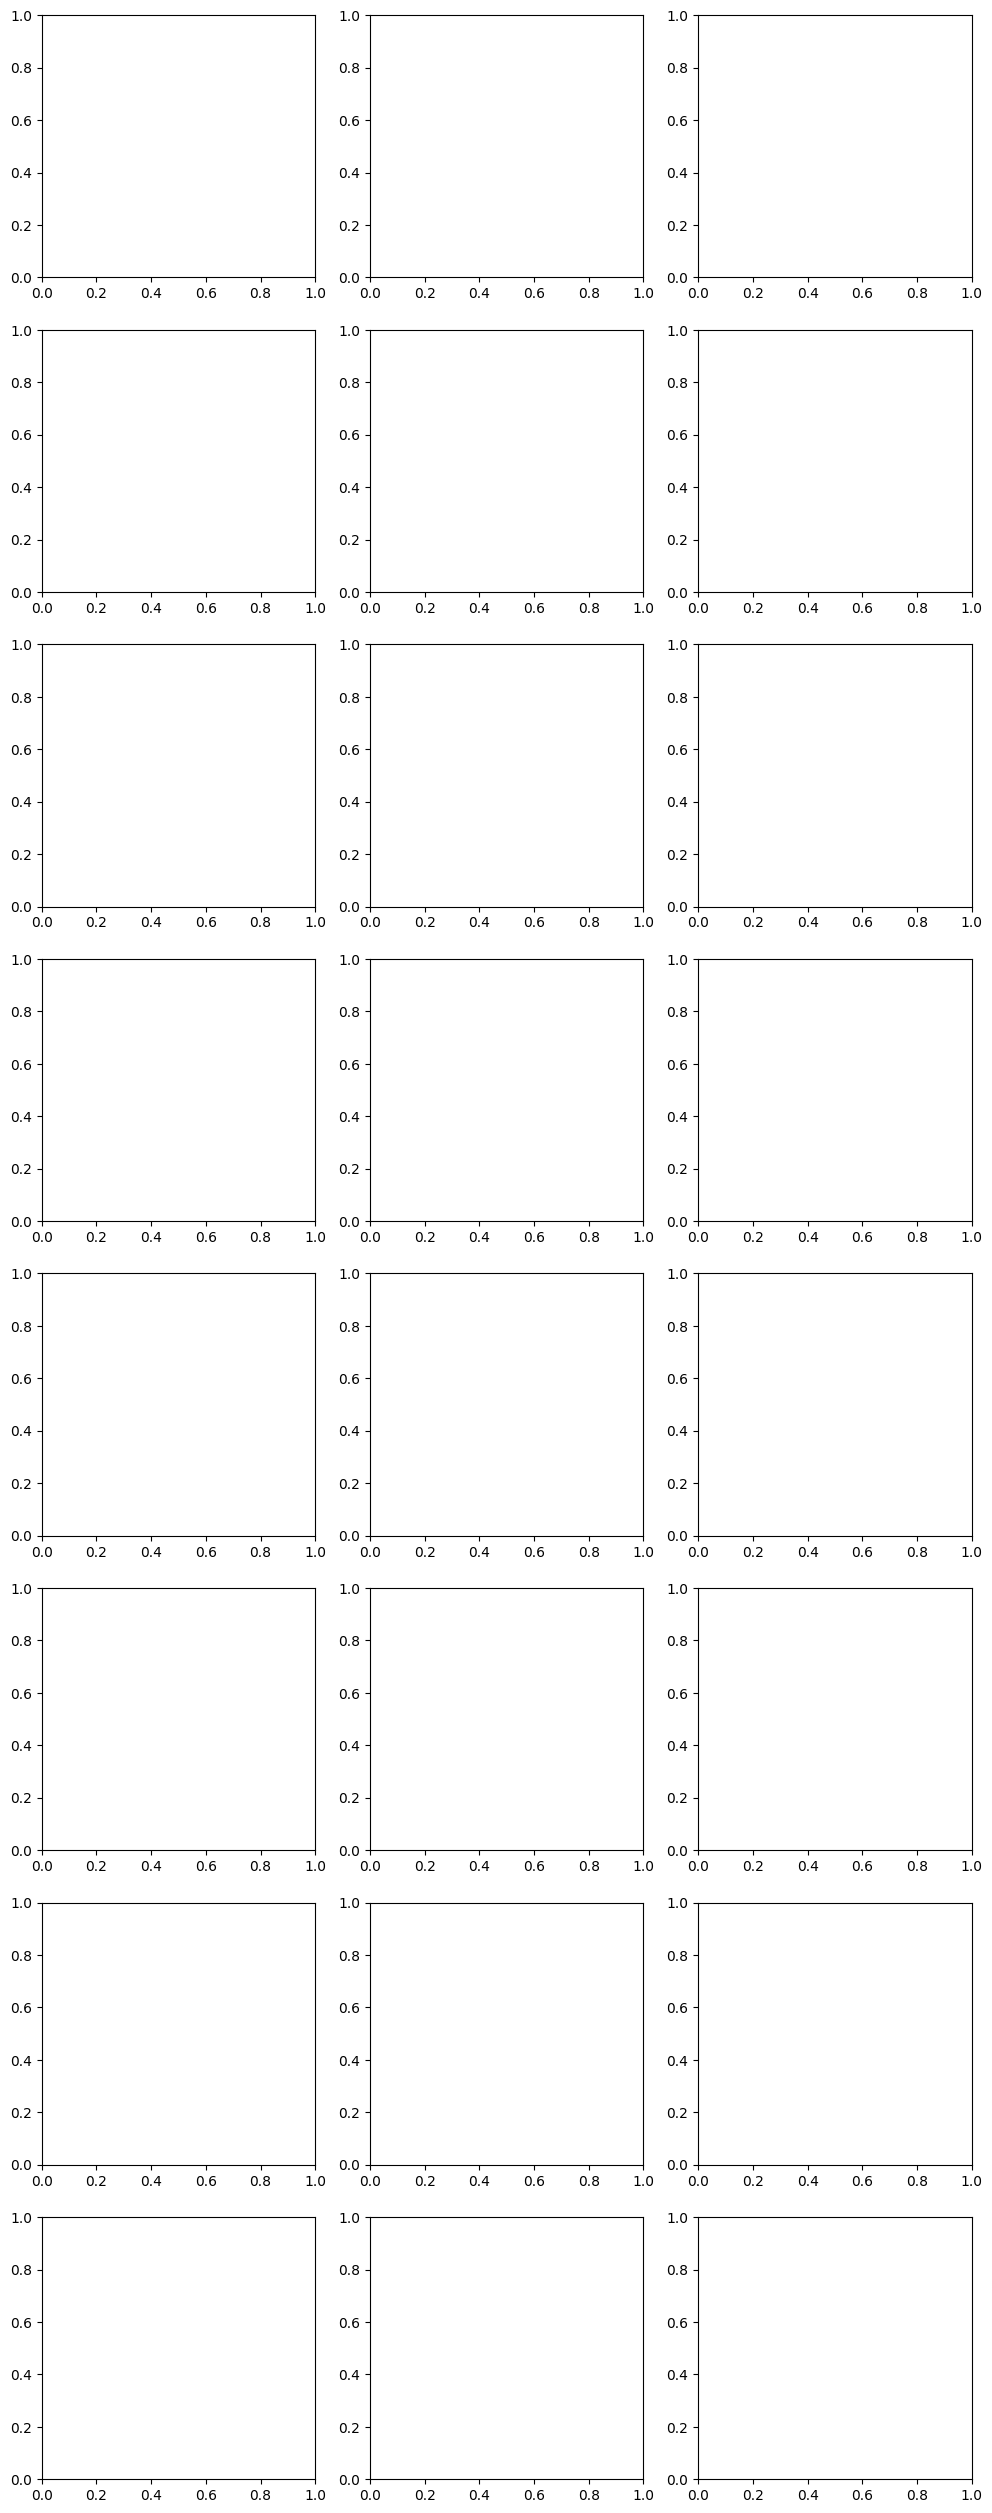

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mplcm
from PIL import Image
import torch
from dataset import denormalize

def attn_rollout(attentions, dr=0.9):
    result = torch.eye(attentions[0].size(-1))
    for attn in attentions:
        attn = attn.squeeze(0).mean(0)
        thr  = attn.view(-1).kthvalue(int(attn.numel()*dr)).values
        attn = torch.where(attn>thr, attn, torch.zeros_like(attn))
        attn = attn/(attn.sum(-1,keepdim=True)+1e-8) + torch.eye(attn.size(-1))
        attn = attn/(attn.sum(-1,keepdim=True)+1e-8)
        result = torch.matmul(attn, result)
    mask = result[0,1:]; w=int(mask.size(0)**0.5)
    mask = mask.reshape(w,w)
    return ((mask-mask.min())/(mask.max()-mask.min()+1e-8)).numpy()

N = 8
indices = np.random.choice(len(test_ds), N, replace=False)
fig, axes = plt.subplots(N, 3, figsize=(12, 4*N))

for i, idx in enumerate(indices):
    img_t, label = test_ds[idx]
    inp = img_t.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        # Force attention output from inner transformer
        vit_out = model.vit.vit(pixel_values=inp, output_attentions=True)
        attns   = vit_out.attentions
        logits, _ = model(inp)
        prob    = torch.softmax(logits, dim=1)[0,1].item()

    orig = denormalize(img_t).permute(1,2,0).numpy()
    tl   = "REAL" if label==0 else "FAKE"
    pl   = "FAKE" if prob>=0.5 else "REAL"
    col  = "green" if tl==pl else "red"

    if attns is not None:
        am  = attn_rollout(attns)
        ar  = np.array(Image.fromarray((am*255).astype(np.uint8)).resize((224,224), Image.BILINEAR))/255.0
        ov  = np.clip(0.55*orig + 0.45*mplcm.jet(ar)[...,:3], 0, 1)
        axes[i][1].imshow(am, cmap="jet")
        axes[i][2].imshow(ov)
    else:
        axes[i][1].text(0.5, 0.5, "N/A", ha="center", va="center")
        axes[i][2].imshow(orig)

    axes[i][0].imshow(orig);         axes[i][0].set_title(f"Original | True: {tl}");              axes[i][0].axis("off")
    axes[i][1].set_title("Attention Map");                                                          axes[i][1].axis("off")
    axes[i][2].set_title(f"Pred: {pl} ({prob:.2f})", color=col);                                   axes[i][2].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/attention_rollout.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done!")

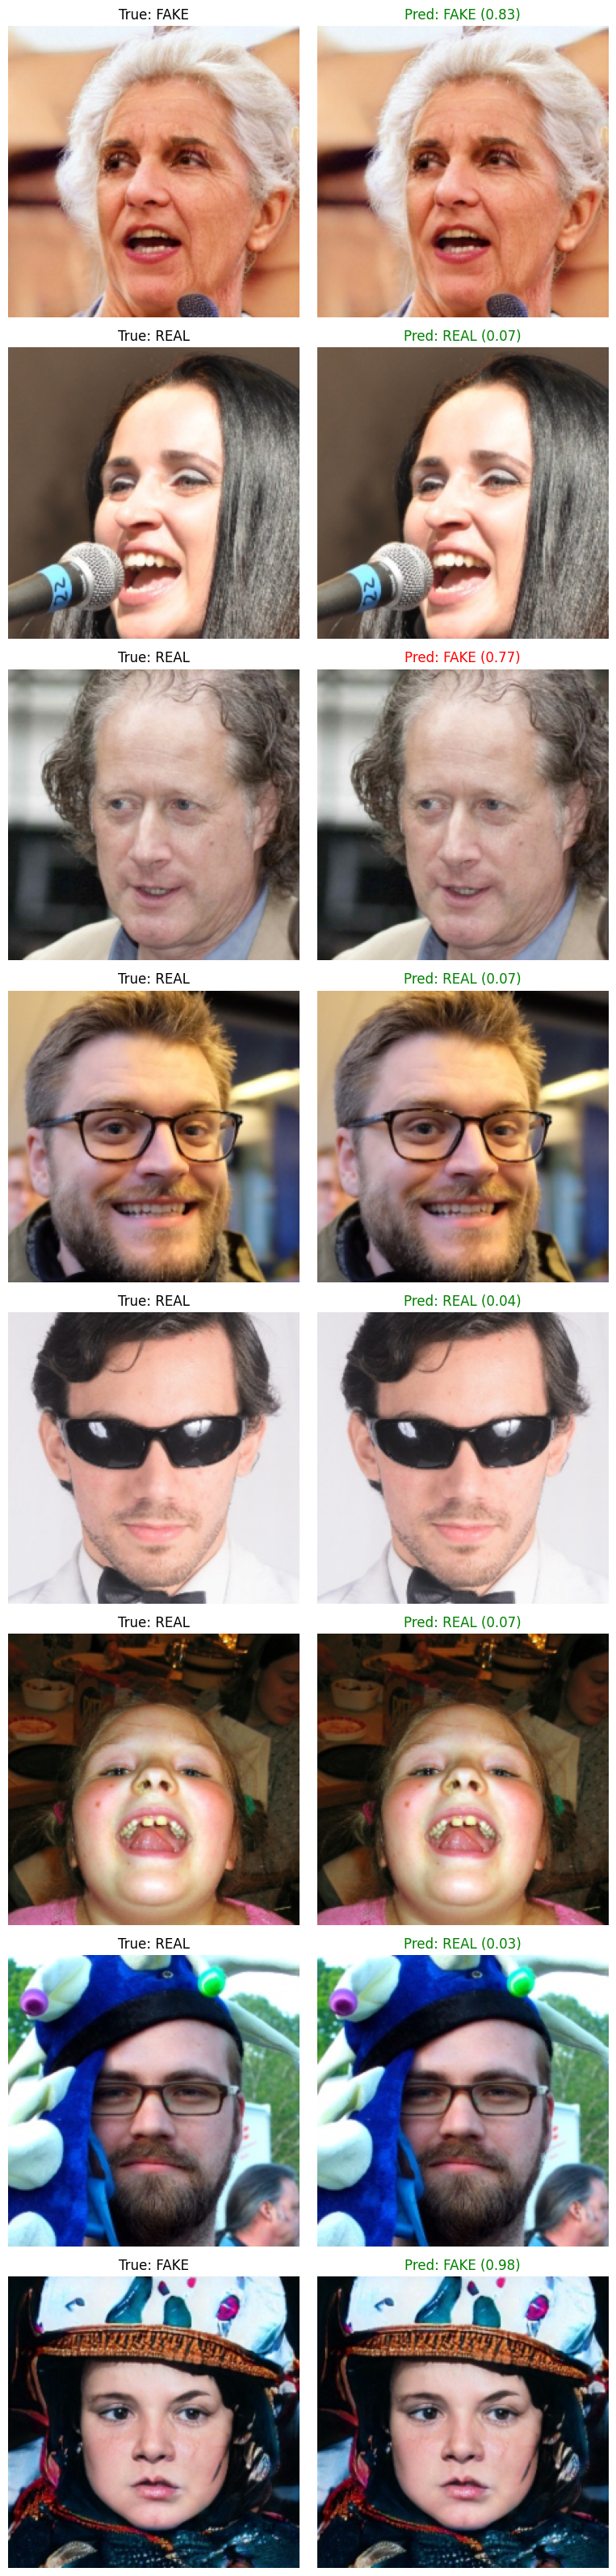

Predictions saved!


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from dataset import denormalize
from PIL import Image
import torch

N = 8
indices = np.random.choice(len(test_ds), N, replace=False)
fig, axes = plt.subplots(N, 2, figsize=(8, 4*N))

for i, idx in enumerate(indices):
    img_t, label = test_ds[idx]
    inp = img_t.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits, _ = model(inp)
        prob = torch.softmax(logits, dim=1)[0,1].item()

    orig = denormalize(img_t).permute(1,2,0).numpy()
    tl   = "REAL" if label==0 else "FAKE"
    pl   = "FAKE" if prob>=0.5 else "REAL"
    col  = "green" if tl==pl else "red"

    axes[i][0].imshow(orig)
    axes[i][0].set_title(f"True: {tl}", fontsize=12)
    axes[i][0].axis("off")

    axes[i][1].imshow(orig)
    axes[i][1].set_title(f"Pred: {pl} ({prob:.2f})", fontsize=12, color=col)
    axes[i][1].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Predictions saved!")

## Step 8: Gradio Web App

In [19]:
!pip install -q gradio
import gradio as gr
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.cm as mplcm
from facenet_pytorch import MTCNN
from dataset import get_val_transforms, denormalize
from model import build_model

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = get_val_transforms()
mtcnn     = MTCNN(image_size=224, margin=20, keep_all=False, device=DEVICE, post_process=False)

ckpt  = torch.load("/kaggle/working/checkpoints/best_model.pth", map_location=DEVICE)
model = build_model(pretrained=False).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print("Model loaded!")

def get_face(pil_img):
    try:
        ft = mtcnn(pil_img)
        if ft is not None:
            return Image.fromarray(ft.permute(1,2,0).numpy().astype(np.uint8))
    except: pass
    w, h = pil_img.size; s = min(w,h)
    return pil_img.crop(((w-s)//2,(h-s)//2,(w+s)//2,(h+s)//2)).resize((224,224))

def get_attention_overlay(face, inp):
    try:
        vit_out = model.vit.vit(pixel_values=inp, output_attentions=True)
        attns   = vit_out.attentions
        if attns is None:
            return face
        result = torch.eye(attns[0].size(-1))
        for attn in attns:
            attn = attn.squeeze(0).mean(0)
            thr  = attn.view(-1).kthvalue(int(attn.numel()*0.9)).values
            attn = torch.where(attn>thr, attn, torch.zeros_like(attn))
            attn = attn/(attn.sum(-1,keepdim=True)+1e-8) + torch.eye(attn.size(-1))
            attn = attn/(attn.sum(-1,keepdim=True)+1e-8)
            result = torch.matmul(attn, result)
        mask = result[0,1:]; w=int(mask.size(0)**0.5)
        mask = mask.reshape(w,w)
        mask = ((mask-mask.min())/(mask.max()-mask.min()+1e-8)).numpy()
        ar   = np.array(Image.fromarray((mask*255).astype(np.uint8)).resize((224,224), Image.BILINEAR))/255.0
        orig = np.array(face.resize((224,224))).astype(np.float32)/255.0
        ov   = np.clip(0.55*orig + 0.45*mplcm.jet(ar)[...,:3], 0, 1)
        return Image.fromarray((ov*255).astype(np.uint8))
    except:
        return face

def predict_image(img):
    if img is None:
        return None, "Please upload an image.", None
    pil  = Image.fromarray(img).convert("RGB")
    face = get_face(pil)
    inp  = transform(face).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits, _ = model(inp)
        prob_fake  = torch.softmax(logits, dim=1)[0,1].item()
        prob_real  = 1 - prob_fake
    label = "FAKE" if prob_fake >= 0.5 else "REAL"
    conf  = prob_fake if prob_fake >= 0.5 else prob_real
    overlay = get_attention_overlay(face, inp)
    result = f"""
## {label}

| | |
|---|---|
| **Fake Probability** | {prob_fake*100:.1f}% |
| **Real Probability** | {prob_real*100:.1f}% |
| **Confidence** | {conf*100:.1f}% |
"""
    return face, result, overlay

def predict_video(video_path):
    if video_path is None:
        return None, "Please upload a video.", None

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None, "Could not open video.", None

    video_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    frame_interval = max(1, int(video_fps))  # 1 frame per second
    MAX_FRAMES = 30

    frames_rgb = []
    frame_idx  = 0
    while len(frames_rgb) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % frame_interval == 0:
            frames_rgb.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frame_idx += 1
    cap.release()

    if not frames_rgb:
        return None, "No frames extracted.", None

    fake_probs   = []
    best_face    = None
    best_overlay = None

    for frame_rgb in frames_rgb:
        try:
            pil  = Image.fromarray(frame_rgb)
            face = get_face(pil)
            inp  = transform(face).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits, _ = model(inp)
                prob_fake  = torch.softmax(logits, dim=1)[0,1].item()
            fake_probs.append(prob_fake)
            if best_face is None:
                best_face    = face
                best_overlay = get_attention_overlay(face, inp)
        except:
            continue

    if not fake_probs:
        return None, "No faces detected in video.", None

    avg_fake = float(np.mean(fake_probs))
    avg_real = 1 - avg_fake
    label    = "FAKE" if avg_fake >= 0.5 else "REAL"
    conf     = avg_fake if avg_fake >= 0.5 else avg_real

    result = f"""
## {label}

| | |
|---|---|
| **Fake Probability** | {avg_fake*100:.1f}% |
| **Real Probability** | {avg_real*100:.1f}% |
| **Confidence** | {conf*100:.1f}% |
| **Frames Analyzed** | {len(fake_probs)} |
"""
    return best_face, result, best_overlay

CSS = """
.gradio-container {
    font-family: 'Segoe UI', sans-serif;
    max-width: 1000px !important;
    margin: auto !important;
}
#title {
    text-align: center;
    background: linear-gradient(135deg, #1a1a2e, #16213e);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin-bottom: 20px;
}
#title h1 { font-size: 2em; margin: 0; }
#title p  { opacity: 0.8; margin: 5px 0 0 0; }
"""

with gr.Blocks(css=CSS, theme=gr.themes.Soft()) as demo:

    gr.HTML("""
    <div id="title">
        <h1>Deepfake Face Detector</h1>
        <p>Powered by Vision Transformer (ViT-B/16) · CS-419 Deep Learning</p>
        <p style="font-size:0.85em">Eshal Fatima · Emaan Khuram Afroze</p>
    </div>
    """)

    with gr.Tabs():

        with gr.Tab("Image Detection"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### Upload Image")
                    img_input = gr.Image(label="Upload a face image", type="numpy", height=280)
                    img_btn   = gr.Button("Analyze Image", variant="primary", size="lg")
                    gr.Markdown("**Tips:** Clear frontal face works best. Supports jpg, png, webp.")
                with gr.Column(scale=1):
                    gr.Markdown("### Results")
                    img_face    = gr.Image(label="Detected Face", type="pil", height=180)
                    img_result  = gr.Markdown()
                    img_overlay = gr.Image(label="Attention Map", type="pil", height=180)
            img_btn.click(fn=predict_image, inputs=[img_input],
                          outputs=[img_face, img_result, img_overlay])

        with gr.Tab("Video Detection"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### Upload Video")
                    vid_input = gr.Video(label="Upload video (mp4, avi, mov)", height=280)
                    vid_btn   = gr.Button("Analyze Video", variant="primary", size="lg")
                    gr.Markdown("**Note:** Analyzes 1 frame per second, up to 30 frames.")
                with gr.Column(scale=1):
                    gr.Markdown("### Results")
                    vid_face    = gr.Image(label="Sample Face Frame", type="pil", height=180)
                    vid_result  = gr.Markdown()
                    vid_overlay = gr.Image(label="Attention Map", type="pil", height=180)
            vid_btn.click(fn=predict_video, inputs=[vid_input],
                          outputs=[vid_face, vid_result, vid_overlay])

    gr.HTML("""
    <div style="text-align:center; padding:20px; color:#666;
                border-top:1px solid #eee; margin-top:20px">
        <p>CS-419 Deep Learning · Dr. Muhammad Imran Malik</p>
        <p>Model: ViT-B/16 fine-tuned on 140k Real & Fake Faces Dataset</p>
    </div>
    """)

demo.launch(share=True, quiet=True)
print("App is live! Open the link above.")

ViT-B/16: 85,997,570 total | 28,551,938 trainable (33.2%)
Model loaded!


/tmp/ipykernel_735/2661940874.py:161: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_735/2661940874.py:161: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, theme=gr.themes.Soft()) as demo:


* Running on public URL: https://574d5a3b96d1a77476.gradio.live


App is live! Open the link above.
